# Experiment A — baryonify halos from *observed* scaling relations

First science use of the observable-conditioned z=0 model. We re-paint held-out CAMELS-TNG halos **twice** from the *same* DMO image and the *same* initial noise:

- **baseline** — condition on the halo's TNG-native R200 observable vector (= reconstruction)
- **observed** — the same vector pushed onto the *observed* relation

**Ratio-anchoring.** Rather than plug absolute literature numbers into the model's idiosyncratic *projected-aperture* observable slots (which would conflate physics with a unit/definition mismatch vs spherical `_500` literature), we multiply each halo's own observable by the dimensionless fractional offset the literature relation has relative to TNG *at that halo's M200*. Same DMO + same noise &rArr; every difference in the painted field is caused purely by moving the observables onto the data.

**Circularity caveat.** `Mgas_200`, `Mstar_200`, `M_200` are themselves conditioning inputs, so f_b *integrated to R200* is ~tautological. We read the **non-conditioned** outputs: f_b(<r) at r&ne;R200, Gas/Stars profile *shapes*, and the hydro-DM contraction `DM_hydro/DMO` (DM_hydro is an output).

Kernel: **torch3** (GPU). Env overrides: `OBS_RUN_DIR`, `OBS_CKPT`, `BIND_DATA_ROOT`, `N_HALOS`, `GAS_ONLY`.

In [1]:
%matplotlib inline
import os, re
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from bind.data import (load_file_list, AstroDataset, NormStats, THERMO_KEYS,
                       OBSERVABLE_KEYS, N_OBS, PIX_MPC_H, compute_observables,
                       r200_from_sample, thermo_forward)
from bind.train import FlowMatchingLit
from bind.inference.pipeline import _denormalize_to_physical

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_DIR   = Path(os.environ.get('OBS_RUN_DIR', '/mnt/home/mlee1/ceph/fm_runs/fm_observables_masked'))
CKPT      = os.environ.get('OBS_CKPT', 'last.ckpt')
DATA_ROOT = Path(os.environ.get('BIND_DATA_ROOT', '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu'))
N_HALOS   = int(os.environ.get('N_HALOS', 64))
N_STEPS   = 50
BATCH     = 16
GAS_ONLY  = os.environ.get('GAS_ONLY', '0') == '1'
CHANNELS  = ['DM_hydro', 'Gas', 'Stars'] + list(THERMO_KEYS)
IDX       = {'DM': 0, 'Gas': 1, 'Stars': 2}
print('device', device, '| N_HALOS', N_HALOS, '| GAS_ONLY', GAS_ONLY)

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


device cuda | N_HALOS 64 | GAS_ONLY False


## Literature scaling relations &mdash; the editable knobs

`ratio = observed / TNG` as a function of `log10(M200c/[Msun/h])`. The X-ray group gas deficit is the headline; the rest are secondary. **Tweak these and re-run from the painting cell down.**

In [2]:
def _gas_ratio(logm):
    """X-ray group gas-fraction deficit vs TNG: ~0.45 at 1e13, closing to 1 by 1e14.5.
    Sun+2009, Lovisari+2015, Eckert+2016 (XXL), eROSITA (Popesso+24 / Bahar+24)."""
    return np.clip(0.45 + (logm - 13.0) * (1.0 - 0.45) / (14.5 - 13.0), 0.45, 1.0)

LIT_RATIOS = {
    'Y_200':     lambda logm: 0.85,   # SZ pressure / hydrostatic-bias deficit (Planck 2013 XX; Henson+17)
    'Mgas_200':  _gas_ratio,          # headline X-ray gas deficit
    'Mstar_200': lambda logm: 0.90,   # SHMR slightly below TNG (Kravtsov+18; Behroozi+19)
    'Tx_200':    lambda logm: 0.95,   # T_X normalization (Vikhlinin+09; Lovisari+15)
    'K_200':     lambda logm: 1.15,   # group entropy excess (Sun+09; Pratt+10)
    'P_200':     lambda logm: 0.85,   # pressure, tracks Y
    'M_200':     lambda logm: 1.00,   # lensing anchor -- held fixed
}
if GAS_ONLY:
    LIT_RATIOS = {k: (LIT_RATIOS[k] if k == 'Mgas_200' else (lambda lm: 1.0)) for k in OBSERVABLE_KEYS}

def lit_ratio_vector(logm):
    return np.array([float(LIT_RATIOS[k](logm)) for k in OBSERVABLE_KEYS], dtype=np.float64)

for lm in (13.0, 13.5, 14.0, 14.5):
    print(f'logM={lm}:', dict(zip(OBSERVABLE_KEYS, np.round(lit_ratio_vector(lm), 2))))

logM=13.0: {'Y_200': 0.85, 'Mgas_200': 0.45, 'Mstar_200': 0.9, 'Tx_200': 0.95, 'K_200': 1.15, 'P_200': 0.85, 'M_200': 1.0}
logM=13.5: {'Y_200': 0.85, 'Mgas_200': 0.63, 'Mstar_200': 0.9, 'Tx_200': 0.95, 'K_200': 1.15, 'P_200': 0.85, 'M_200': 1.0}
logM=14.0: {'Y_200': 0.85, 'Mgas_200': 0.82, 'Mstar_200': 0.9, 'Tx_200': 0.95, 'K_200': 1.15, 'P_200': 0.85, 'M_200': 1.0}
logM=14.5: {'Y_200': 0.85, 'Mgas_200': 1.0, 'Mstar_200': 0.9, 'Tx_200': 0.95, 'K_200': 1.15, 'P_200': 0.85, 'M_200': 1.0}


In [3]:
def cumulative_in_radii(field, radii_mpc):
    """Cumulative sum of `field` within each circular aperture radius (Mpc/h)."""
    n = field.shape[-1]
    c = (n - 1) / 2.0
    yy, xx = np.mgrid[:n, :n]
    rr = np.hypot(xx - c, yy - c) * PIX_MPC_H
    return np.array([float(field[rr < r].sum()) for r in radii_mpc])

## Load the observable-conditioned model + held-out halos

In [4]:
ns = NormStats.load(RUN_DIR / 'norm_stats.npz')
assert ns.condition_observables, 'run is not observable-conditioned'
ckpt = RUN_DIR / 'checkpoints' / CKPT
model = FlowMatchingLit.load_from_checkpoint(str(ckpt), map_location=device).eval().to(device)
fm = model.fm
_ep = re.search(r'epoch(\d+)', ckpt.name)
print(f'loaded {ckpt.name} (epoch {_ep.group(1) if _ep else "?"}); '
      f'predict_thermo={ns.predict_thermo} stars_two_head={ns.stars_two_head} '
      f'mask_observables={ns.mask_observables}')

# mask-awareness: a --mask_observables model takes a 2*N_OBS [obs*mask, mask] vector.
# Disable the dataset's random training-time masking (we want deterministic full obs),
# and pack explicitly with make_cond (all-ones mask = full observation).
MASKED = bool(ns.mask_observables)
ns.mask_observables = False

def make_cond(obs_norm, keep=None):
    """(B, N_OBS) normalized observables -> model conditioning (numpy). Masked model:
    (B, 2*N_OBS) [obs*keep, keep], keep defaults to all-ones. Unmasked: unchanged."""
    obs_norm = np.asarray(obs_norm, dtype=np.float32)
    if not MASKED:
        return obs_norm
    keep = (np.ones_like(obs_norm) if keep is None
            else np.broadcast_to(np.asarray(keep, np.float32), obs_norm.shape))
    return np.concatenate([obs_norm * keep, keep], axis=1).astype(np.float32)

files = load_file_list(str(DATA_ROOT), 'test')
ds = AstroDataset(files, ns)
rng = np.random.default_rng(0)
idx = rng.choice(len(ds), size=min(N_HALOS, len(ds)), replace=False)
print(f'{len(idx)} halos from {len(files)} held-out files | MASKED={MASKED}')

loaded last.ckpt (epoch ?); predict_thermo=True stars_two_head=True mask_observables=True
64 halos from 42720 held-out files | MASKED=True


## Paint each halo twice (baseline TNG obs vs observed-relation obs)

Same DMO and same noise seed per batch &rArr; the difference is purely the observable shift.

In [5]:
def paint(cond, ls, obs_norm, seed):
    torch.manual_seed(seed)
    with torch.no_grad():
        g = fm.sample(cond, ls, torch.from_numpy(make_cond(obs_norm)).to(device), n_steps=N_STEPS)
    return _denormalize_to_physical(g.float().cpu().numpy(), ns)

base_all, obs_all, dmo_all, r200_all, logm_all = [], [], [], [], []
for s in range(0, len(idx), BATCH):
    sub = idx[s:s + BATCH]
    items = [ds[i] for i in sub]
    cond = torch.stack([it['condition'] for it in items]).to(device)
    ls   = torch.stack([it['large_scale'] for it in items]).to(device)
    base_obs_norm = np.stack([it['params'].numpy() for it in items])      # already-normalized TNG obs (N_OBS)
    obs_obs_norm  = np.empty_like(base_obs_norm)
    for k, i in enumerate(sub):
        d = np.load(files[i])
        raw  = compute_observables(d)                                     # physical TNG obs
        logm = np.log10(float(d['halo_mass']))
        shifted = raw * lit_ratio_vector(logm)
        obs_obs_norm[k] = thermo_forward(shifted[None], ns.obs_mean[None], ns.obs_std[None], ns.obs_floor[None])[0]
        dmo_all.append(d['condition'].astype(np.float32))
        r200_all.append(r200_from_sample(d)); logm_all.append(logm)
    base_all.append(paint(cond, ls, base_obs_norm, seed=1000 + s)[:, :3])  # make_cond packs mask if MASKED
    obs_all.append( paint(cond, ls, obs_obs_norm,  seed=1000 + s)[:, :3])  # same seed -> same noise
    print(f'  batch {s//BATCH}: {len(sub)} halos done')

base = np.concatenate(base_all)   # (N,3,H,W) [DM_hydro, Gas, Stars]
obs  = np.concatenate(obs_all)
dmo  = np.stack(dmo_all)
r200 = np.array(r200_all); logm = np.array(logm_all)
rmed = float(np.median(r200))
print(f'painted base {base.shape}; logM200 {logm.min():.2f}-{logm.max():.2f}; median R200 {rmed:.2f} Mpc/h')

  batch 0: 16 halos done
  batch 1: 16 halos done
  batch 2: 16 halos done
  batch 3: 16 halos done
painted base (64, 3, 128, 128); logM200 13.01-14.82; median R200 0.43 Mpc/h


In [6]:
radii = np.linspace(0.1, 3.0, 24)   # Mpc/h apertures
def cum(stack, ch):
    return np.stack([cumulative_in_radii(stack[i, ch], radii) for i in range(len(stack))])

cb   = {n: cum(base, IDX[n]) for n in IDX}
co   = {n: cum(obs,  IDX[n]) for n in IDX}
cdmo = np.stack([cumulative_in_radii(dmo[i], radii) for i in range(len(dmo))])

fb_base = (cb['Gas'] + cb['Stars']) / (cb['DM'] + cb['Gas'] + cb['Stars'] + 1e-30)
fb_obs  = (co['Gas'] + co['Stars']) / (co['DM'] + co['Gas'] + co['Stars'] + 1e-30)
contr_base = cb['DM'] / (cdmo + 1e-30)
contr_obs  = co['DM'] / (cdmo + 1e-30)

## Result 1 &mdash; baryon fraction profile f_b(<r)

Inner radii (r &ne; R200) are genuine predictions, not echoes of the integrated input.

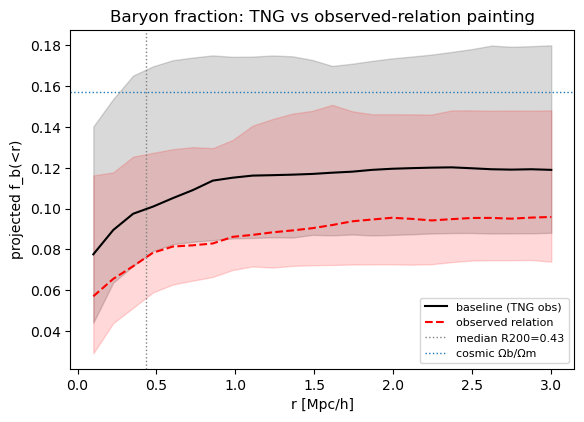

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.plot(radii, np.median(fb_base, 0), 'k-', label='baseline (TNG obs)')
ax.fill_between(radii, *np.percentile(fb_base, [16, 84], 0), color='k', alpha=0.15)
ax.plot(radii, np.median(fb_obs, 0), 'r--', label='observed relation')
ax.fill_between(radii, *np.percentile(fb_obs, [16, 84], 0), color='r', alpha=0.15)
ax.axvline(rmed, ls=':', color='gray', lw=1, label=f'median R200={rmed:.2f}')
ax.axhline(0.157, ls=':', color='C0', lw=1, label='cosmic \u03a9b/\u03a9m')
ax.set_xlabel('r [Mpc/h]'); ax.set_ylabel('projected f_b(<r)')
ax.set_title('Baryon fraction: TNG vs observed-relation painting')
ax.legend(fontsize=8); plt.show()

## Result 2 &mdash; hydro-DM contraction (DM_hydro is an *output*)

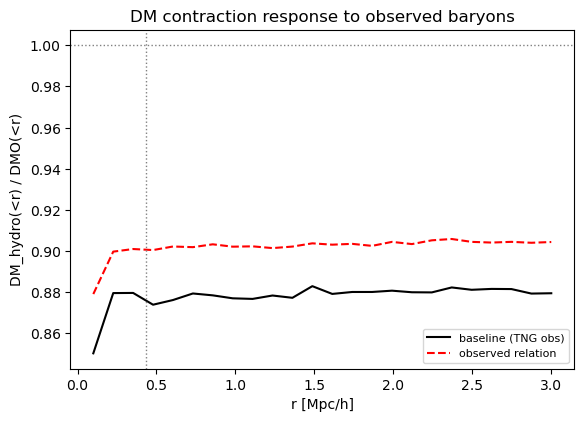

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.plot(radii, np.median(contr_base, 0), 'k-', label='baseline (TNG obs)')
ax.plot(radii, np.median(contr_obs, 0), 'r--', label='observed relation')
ax.axvline(rmed, ls=':', color='gray', lw=1); ax.axhline(1.0, ls=':', color='gray', lw=1)
ax.set_xlabel('r [Mpc/h]'); ax.set_ylabel('DM_hydro(<r) / DMO(<r)')
ax.set_title('DM contraction response to observed baryons')
ax.legend(fontsize=8); plt.show()

## Result 3 &mdash; Gas / Stars cumulative-mass response (observed / baseline)

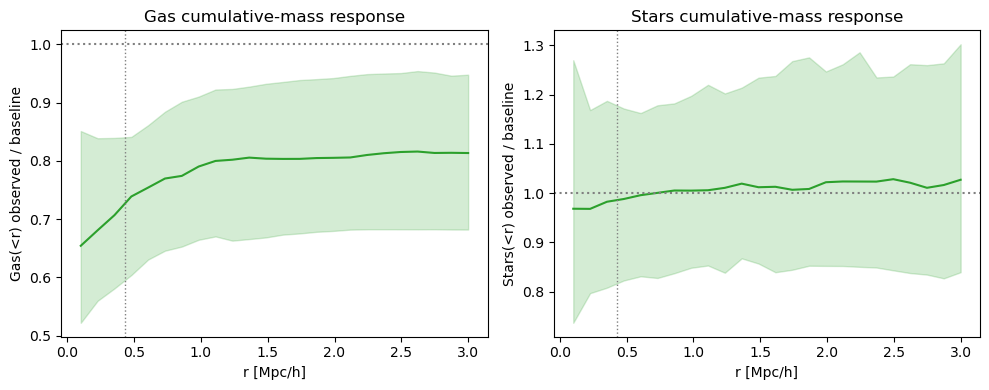

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, n in zip(axes, ['Gas', 'Stars']):
    ratio = co[n] / (cb[n] + 1e-30)
    ax.plot(radii, np.median(ratio, 0), 'C2-')
    ax.fill_between(radii, *np.percentile(ratio, [16, 84], 0), color='C2', alpha=0.2)
    ax.axhline(1.0, ls=':', color='gray'); ax.axvline(rmed, ls=':', color='gray', lw=1)
    ax.set_xlabel('r [Mpc/h]'); ax.set_ylabel(f'{n}(<r) observed / baseline')
    ax.set_title(f'{n} cumulative-mass response')
plt.tight_layout(); plt.show()

## Summary table (read the inner radii especially)

In [10]:
def at(r):
    return int(np.argmin(np.abs(radii - r)))
print('  r[Mpc/h]   f_b base   f_b obs     df_b     DMcontr base/obs')
for r in (0.2, 0.5, 1.0, rmed, 2.0):
    i = at(r)
    print(f'  {radii[i]:7.2f}  {np.median(fb_base[:, i]):8.3f}  {np.median(fb_obs[:, i]):8.3f}  '
          f'{np.median(fb_obs[:, i]-fb_base[:, i]):+8.3f}   '
          f'{np.median(contr_base[:, i]):.3f}/{np.median(contr_obs[:, i]):.3f}')

  r[Mpc/h]   f_b base   f_b obs     df_b     DMcontr base/obs
     0.23     0.089     0.066    -0.025   0.880/0.900
     0.48     0.101     0.078    -0.027   0.874/0.900
     0.98     0.115     0.086    -0.024   0.877/0.902
     0.48     0.101     0.078    -0.027   0.874/0.900
     1.99     0.119     0.095    -0.023   0.881/0.904


## Explore a single halo &mdash; map comparison

DMO &rarr; painted Gas (baseline vs observed) and the log-ratio. Change `J` to scan halos (sorted by mass).

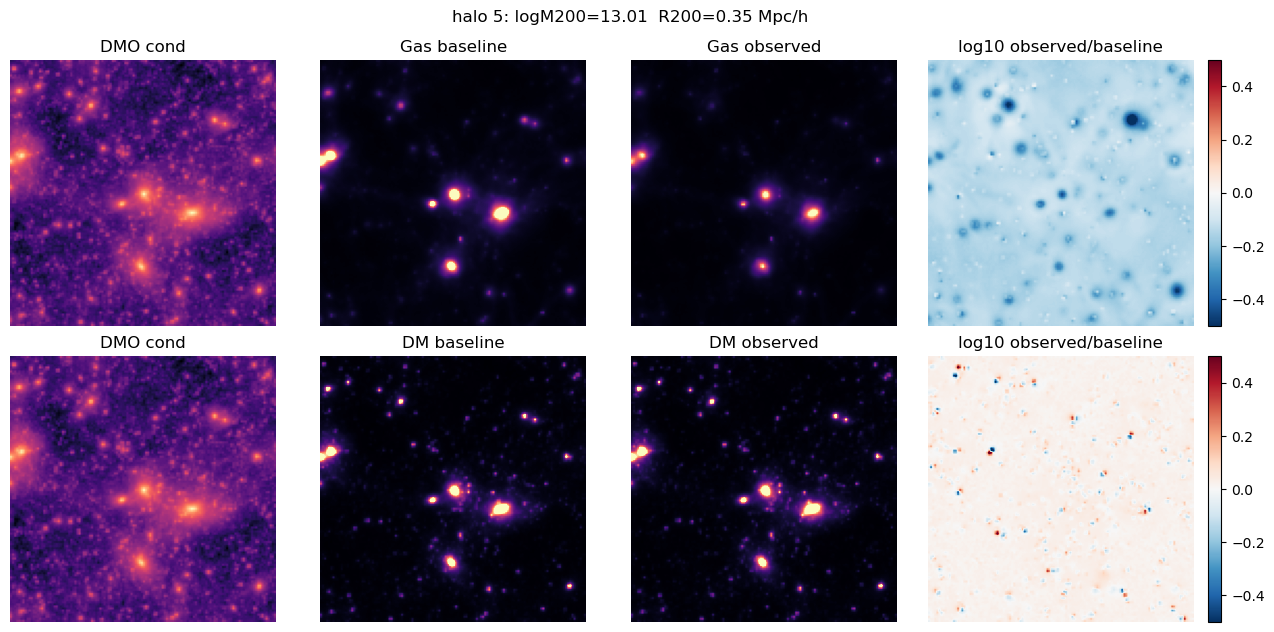

In [11]:
J = 0
order = np.argsort(logm)            # 0 = lowest mass; -1 = highest
j = order[J]
fig, ax = plt.subplots(2, 4, figsize=(13, 6.4))
for row, name in zip(range(2), ['Gas', 'DM']):
    ch = IDX[name]
    b, o = base[j, ch], obs[j, ch]
    vmax = np.percentile(b[b > 0], 99.5) if (b > 0).any() else 1.0
    ax[row, 0].imshow(np.log10(dmo[j] + 1), cmap='magma'); ax[row, 0].set_title('DMO cond')
    ax[row, 1].imshow(b, vmin=0, vmax=vmax, cmap='magma'); ax[row, 1].set_title(f'{name} baseline')
    ax[row, 2].imshow(o, vmin=0, vmax=vmax, cmap='magma'); ax[row, 2].set_title(f'{name} observed')
    im = ax[row, 3].imshow(np.log10((o + 1e-30) / (b + 1e-30)), vmin=-0.5, vmax=0.5, cmap='RdBu_r')
    ax[row, 3].set_title('log10 observed/baseline'); fig.colorbar(im, ax=ax[row, 3], fraction=0.046)
    for c in range(4): ax[row, c].axis('off')
fig.suptitle(f'halo {j}: logM200={logm[j]:.2f}  R200={r200[j]:.2f} Mpc/h')
plt.tight_layout(); plt.show()

## Notes & next steps

- **Non-circular readouts.** f_b(<r) at inner radii, profile shapes, and DM contraction are the trustworthy signals; the R200-integrated f_b is ~fixed by the (Mgas, Mstar, M) inputs.
- **Mass dependence.** Slice `fb_obs - fb_base` by `logm` to see whether the observed gas deficit bites hardest at group scale (it should, given `_gas_ratio`).
- **Isolate knobs.** Set `GAS_ONLY=1` (or edit `LIT_RATIOS`) and re-run from the painting cell to attribute the response to a single observable.
- **The real f_b *prediction*** (condition on Y, Tx, M only; predict Mgas &rarr; f_b) needs an **input-dropout retrain** so the model tolerates a missing subset &mdash; the same capability that unlocks real-survey and cross-sim (SIMBA/EAGLE) use.